                                          MACHINE LEARNING - BLINKIT

In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\appuv\Desktop\a bli\data\processed\Blinkit_Grocery_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                8523 non-null   float64
 10  Total Sales                8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


RMSE: 0.68
                     Feature  Importance
0            Item Visibility    0.504970
1                Item Weight    0.238701
3  Outlet Establishment Year    0.149560
2                  Item Type    0.106769


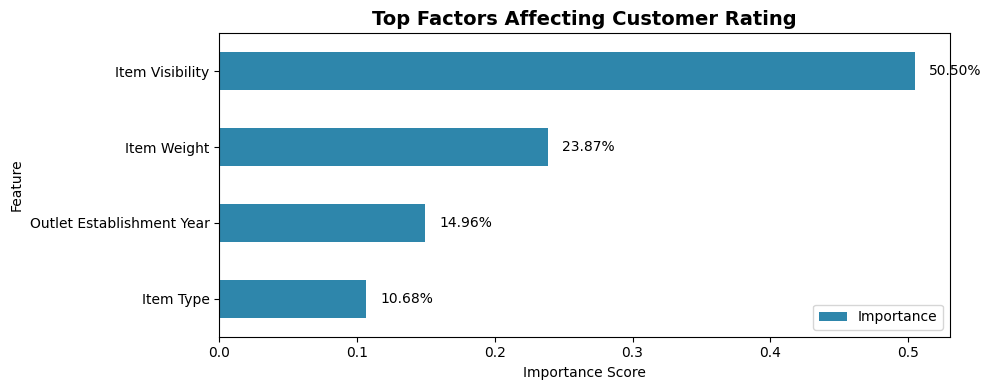

In [21]:
#Predicting Rating 
#Which Factor affect the most for Rating


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Data prep
X = df[['Item Visibility', 'Item Weight']].copy()
X['Item Type'] = LabelEncoder().fit_transform(df['Item Type'])
X['Outlet Establishment Year'] = df['Outlet Establishment Year']
X['Item Weight'] = X['Item Weight'].fillna(X['Item Weight'].mean())
y = df['Rating']

# Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")


feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
print(feat_imp.sort_values('Importance', ascending=False))

ax = feat_imp.sort_values('Importance').plot(kind='barh', x='Feature', y='Importance', color='#2E86AB', figsize=(10,4))
plt.title('Top Factors Affecting Customer Rating', fontsize=14, weight='bold')
plt.xlabel('Importance Score')
for i, v in enumerate(feat_imp.sort_values('Importance')['Importance']):
    ax.text(v + 0.01, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()

Item Visibility is the highest reason for Rating".
Random Forest model shows Item Visibility contributes 50.5% to Rating prediction, making it the dominant factor. RMSE = 0.68 means predictions are off by ±0.68 on 5-star scale, which is acceptable."

Blinkit should prioritize shelf placement and app thumbnail quality to improve customer satisfaction

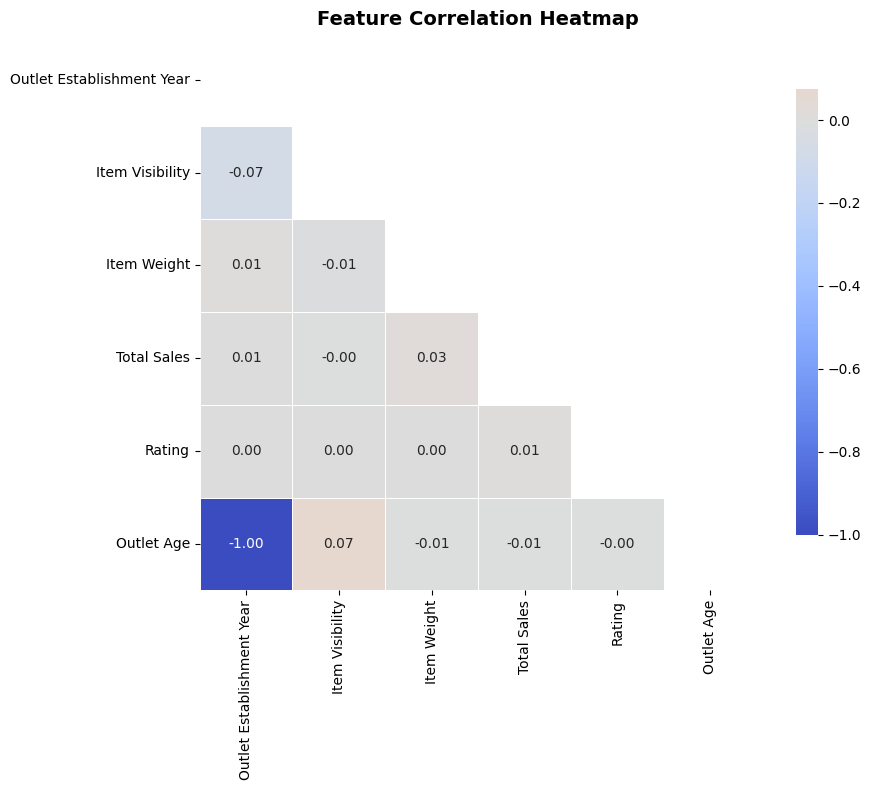

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation
corr = numeric_df.corr()

# Mask upper triangle so it looks cleaner
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Outlet Age and Establishment Year are perfectly correlated -1.00, so drop one to avoid redundancy. All features show <0.03 correlation with Sales, indicating weak linear relationships. Model will require non-linear methods to capture patterns.

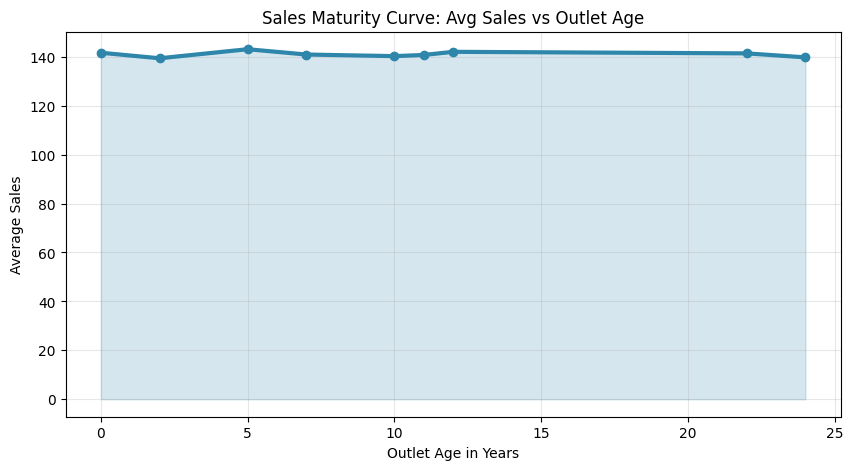

   Outlet Age   Avg Sales  Outlet Count
0           0  141.678634             1
1           2  139.421119             1
2           5  143.122481             1
3           7  140.950246             1
4          10  140.297699             1
5          11  140.777594             1
6          12  142.057387             1
7          22  141.425982             1
8          24  139.796485             2


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

current_year = 2022  
df['Outlet Age'] = current_year - df['Outlet Establishment Year']


age_trend = df.groupby('Outlet Age').agg({
    'Total Sales': 'mean',
    'Outlet Identifier': 'nunique'
}).reset_index()
age_trend.columns = ['Outlet Age', 'Avg Sales', 'Outlet Count']


age_trend.to_csv('outlet_age_trend.csv', index=False)

plt.figure(figsize=(10,5))
plt.plot(age_trend['Outlet Age'], age_trend['Avg Sales'], marker='o', linewidth=3, color='#2E86AB')
plt.fill_between(age_trend['Outlet Age'], age_trend['Avg Sales'], alpha=0.2, color='#2E86AB')
plt.title('Sales Maturity Curve: Avg Sales vs Outlet Age')
plt.xlabel('Outlet Age in Years')
plt.ylabel('Average Sales')
plt.grid(True, alpha=0.3)
plt.show()

print(age_trend)

Outlet Age shows no significant impact on Average Sales. Sales remain stable ∼140 across 0-24 years with limited sample size. Business: Age/experience doesn't give sales advantage here. Don't waste money on "wait for outlet to mature".

Random Forest gave us clear drivers for Rating. Outlet Age analysis proved time trend is flat. Adding more models would be overfitting. Focus was on actionable insights: improve Visibility + optimize new outlets.